# PAYE Revenue–Equity Simulation Grid

This notebook evaluates the **revenue and distributional effects of alternative PAYE tax rate structures** using administrative employment income data for 2024, a population of 3,065,165 tax payers .

The analysis starts from the **current Kenyan PAYE structure**, defined by five marginal tax bands. The first band rate and personal relief are held constant, while the remaining marginal rates are varied within a structured grid.

## Simulated PAYE Rate Grid

The simulation explores combinations of the following marginal tax rates:

- **Band 2 rate (r2):** 25% – 30%  
- **Band 3 rate (r3):** 30% – 32.5%  
- **Band 4 rate (r4):** 32.5% – 35%  
- **Band 5 rate (r5):** 35% – 40%

## Metrics Computed

For each tax system in the grid we compute:

- **Total PAYE revenue**
- **Revenue change relative to the baseline**
- **Concentration index of tax payments**
- **Kakwani progressivity index**

## Policy Analysis

The resulting policy space is analyzed to identify the **Pareto frontier of efficient tax systems**, highlighting the trade-off between:

- **Revenue generation**
- **Tax progressivity**

## Outputs

The notebook produces:

- A **simulation grid of PAYE rate combinations**
- **Summary tables** of key outcomes
- A **visual dashboard** describing the revenue–equity policy frontier

## 1. Import Libraries 

We import the neccessary libraries here

In [ ]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

# Data manipulation
import pandas as pd
import numpy as np

# Iteration for simulation grid
import itertools

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# File and path management
from pathlib import Path

# Plot settings
plt.style.use("default")
sns.set_style("whitegrid")

# Display settings for pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 2. Load and Clean PAYE Data

In [4]:
# ============================================================
# 2. LOAD AND CLEAN PAYE DATA
# ============================================================

# path to PAYE dataset
data_path = r"C:\Users\hp\OneDrive\Documents\PAYE simulation grid\paye_combined_raw.dta"

# load dataset
df = pd.read_stata(data_path)

# convert income variable to numeric
df["tot_gross_pay"] = pd.to_numeric(df["tot_gross_pay"], errors="coerce")

# drop missing or invalid records
df = df.dropna(subset=["tax_payer_id", "tot_gross_pay"]).copy()

# keep only non-negative income
df = df[df["tot_gross_pay"] >= 0].copy()

print("Records after cleaning:", len(df))

# preview
df.head()

Records after cleaning: 3065165


,tax_payer_id,tot_gross_pay
0,14210625,2.078351e+08
1,14210625,2.078351e+08
2,17394822,1.961275e+08
3,17394822,1.961275e+08
4,15323387,1.803102e+08


## 3. Construct Annual Taxable Employment Income

In [5]:
# ============================================================
# 3. CONSTRUCT ANNUAL TAXABLE EMPLOYMENT INCOME
# ============================================================

# Gross annual employment income
H = df["tot_gross_pay"].astype(float)

# Statutory deductions

# SHIF contribution (2.75% of income with minimum of 3,600)
df["SHIF"] = np.maximum(0.0275 * H, 3600)

# Affordable Housing Fund (1.5%)
df["AHF"] = 0.015 * H

# NSSF Tier II capped contribution
df["NSSF"] = np.minimum(0.06 * H, 51840)

# Construct taxable employment income
df["Taxable_Employment_Income"] = np.maximum(
    H - df["SHIF"] - df["AHF"] - df["NSSF"],
    0.0
)

# Convert to numpy array 
R = df["Taxable_Employment_Income"].to_numpy(dtype=float)

print("Taxable income constructed.")
print("Mean taxable income:", df["Taxable_Employment_Income"].mean())
print("Median taxable income:", df["Taxable_Employment_Income"].median())

df[["tot_gross_pay","SHIF","AHF","NSSF","Taxable_Employment_Income"]].head()

Taxable income constructed.
Mean taxable income: 767116.6332222987
Median taxable income: 368872.5


,tot_gross_pay,SHIF,AHF,NSSF,Taxable_Employment_Income
0,2.078351e+08,5.715466e+06,3.117527e+06,51840.0,1.989503e+08
1,2.078351e+08,5.715466e+06,3.117527e+06,51840.0,1.989503e+08
2,1.961275e+08,5.393506e+06,2.941912e+06,51840.0,1.877402e+08
3,1.961275e+08,5.393506e+06,2.941912e+06,51840.0,1.877402e+08
4,1.803102e+08,4.958531e+06,2.704653e+06,51840.0,1.725952e+08


## 4. Define PAYE Tax Parameters and Baseline Structure

In [6]:
# ============================================================
# 4. DEFINE PAYE TAX PARAMETERS AND BASELINE STRUCTURE
# ============================================================

# PAYE band thresholds (annual taxable income)
b1 = 288_000
b2 = 387_996
b3 = 6_000_000
b4 = 9_600_000

# Personal relief (annual)
relief = 28_800

# Baseline marginal tax rates
r1_base = 0.10
r2_base = 0.25
r3_base = 0.30
r4_base = 0.325
r5_base = 0.35

print("Baseline PAYE structure loaded.")
print(f"Band 1: first {b1:,.0f} at {r1_base:.1%}")
print(f"Band 2: next {b2-b1:,.0f} at {r2_base:.1%}")
print(f"Band 3: next {b3-b2:,.0f} at {r3_base:.1%}")
print(f"Band 4: next {b4-b3:,.0f} at {r4_base:.1%}")
print(f"Band 5: income above {b4:,.0f} at {r5_base:.1%}")
print(f"Personal relief: KES {relief:,.0f} per year")

Baseline PAYE structure loaded.
Band 1: first 288,000 at 10.0%
Band 2: next 99,996 at 25.0%
Band 3: next 5,612,004 at 30.0%
Band 4: next 3,600,000 at 32.5%
Band 5: income above 9,600,000 at 35.0%
Personal relief: KES 28,800 per year


MONTHLY BAND SUMMARY


,monthly_band,employees,paye,taxable_income,employee_share_pct,paye_share_pct,income_share_pct,cum_employee_share_pct,cum_paye_share_pct,cum_income_share_pct,paye_bn,income_bn
0,0-50k,2099379,3.207688e+10,5.247288e+11,68.491549,6.356570,22.316169,68.491549,6.356570,22.316169,32.076879,524.728788
1,50-100k,577384,9.171515e+10,4.816264e+11,18.836963,18.174892,20.483071,87.328512,24.531462,42.799240,91.715152,481.626447
2,100-150k,158892,5.478713e+10,2.310328e+11,5.183799,10.856987,9.825583,92.512312,35.388450,52.624822,54.787133,231.032768
3,150-200k,68518,3.644526e+10,1.423593e+11,2.235377,7.222239,6.054393,94.747689,42.610688,58.679216,36.445263,142.359314
4,200-250k,45519,3.251744e+10,1.222596e+11,1.485042,6.443876,5.199572,96.232731,49.054564,63.878788,32.517444,122.259572
5,250-300k,29593,2.638290e+10,9.695899e+10,0.965462,5.228214,4.123565,97.198193,54.282778,68.002353,26.382903,96.958992
6,300-350k,18029,1.933036e+10,6.992734e+10,0.588190,3.830633,2.973937,97.786383,58.113411,70.976290,19.330356,69.927342
7,350-400k,13042,1.637489e+10,5.855642e+10,0.425491,3.244958,2.490343,98.211874,61.358369,73.466633,16.374889,58.556418
8,400-450k,9077,1.300554e+10,4.611726e+10,0.296134,2.577266,1.961319,98.508009,63.935635,75.427952,13.005542,46.117261
9,450-500k,6828,1.101811e+10,3.880731e+10,0.222761,2.183424,1.650434,98.730770,66.119059,77.078387,11.018115,38.807308


ANNUAL BAND SUMMARY


,annual_band,employees,paye,taxable_income,employee_share_pct,paye_share_pct,income_share_pct,cum_employee_share_pct,cum_paye_share_pct,cum_income_share_pct,paye_bn,income_bn
0,0-288k,1297089,0.000000e+00,1.758819e+11,42.317102,0.000000,7.480074,42.317102,0.000000,7.480074,0.000000,175.881899
1,288k-388k,283293,3.322251e+09,9.487739e+10,9.242341,0.658360,4.035036,51.559443,0.658360,11.515110,3.322251,94.877387
2,388k-6.0m,1445879,3.303314e+11,1.541615e+12,47.171327,65.460699,65.563276,98.730770,66.119059,77.078387,330.331426,1541.614924
3,6.0m-9.6m,20148,4.418458e+10,1.509179e+11,0.657322,8.755915,6.418380,99.388092,74.874974,83.496766,44.184584,150.917868
4,9.6m+,18756,1.267873e+11,3.880470e+11,0.611908,25.125026,16.503234,100.000000,100.000000,100.000000,126.787307,388.046977


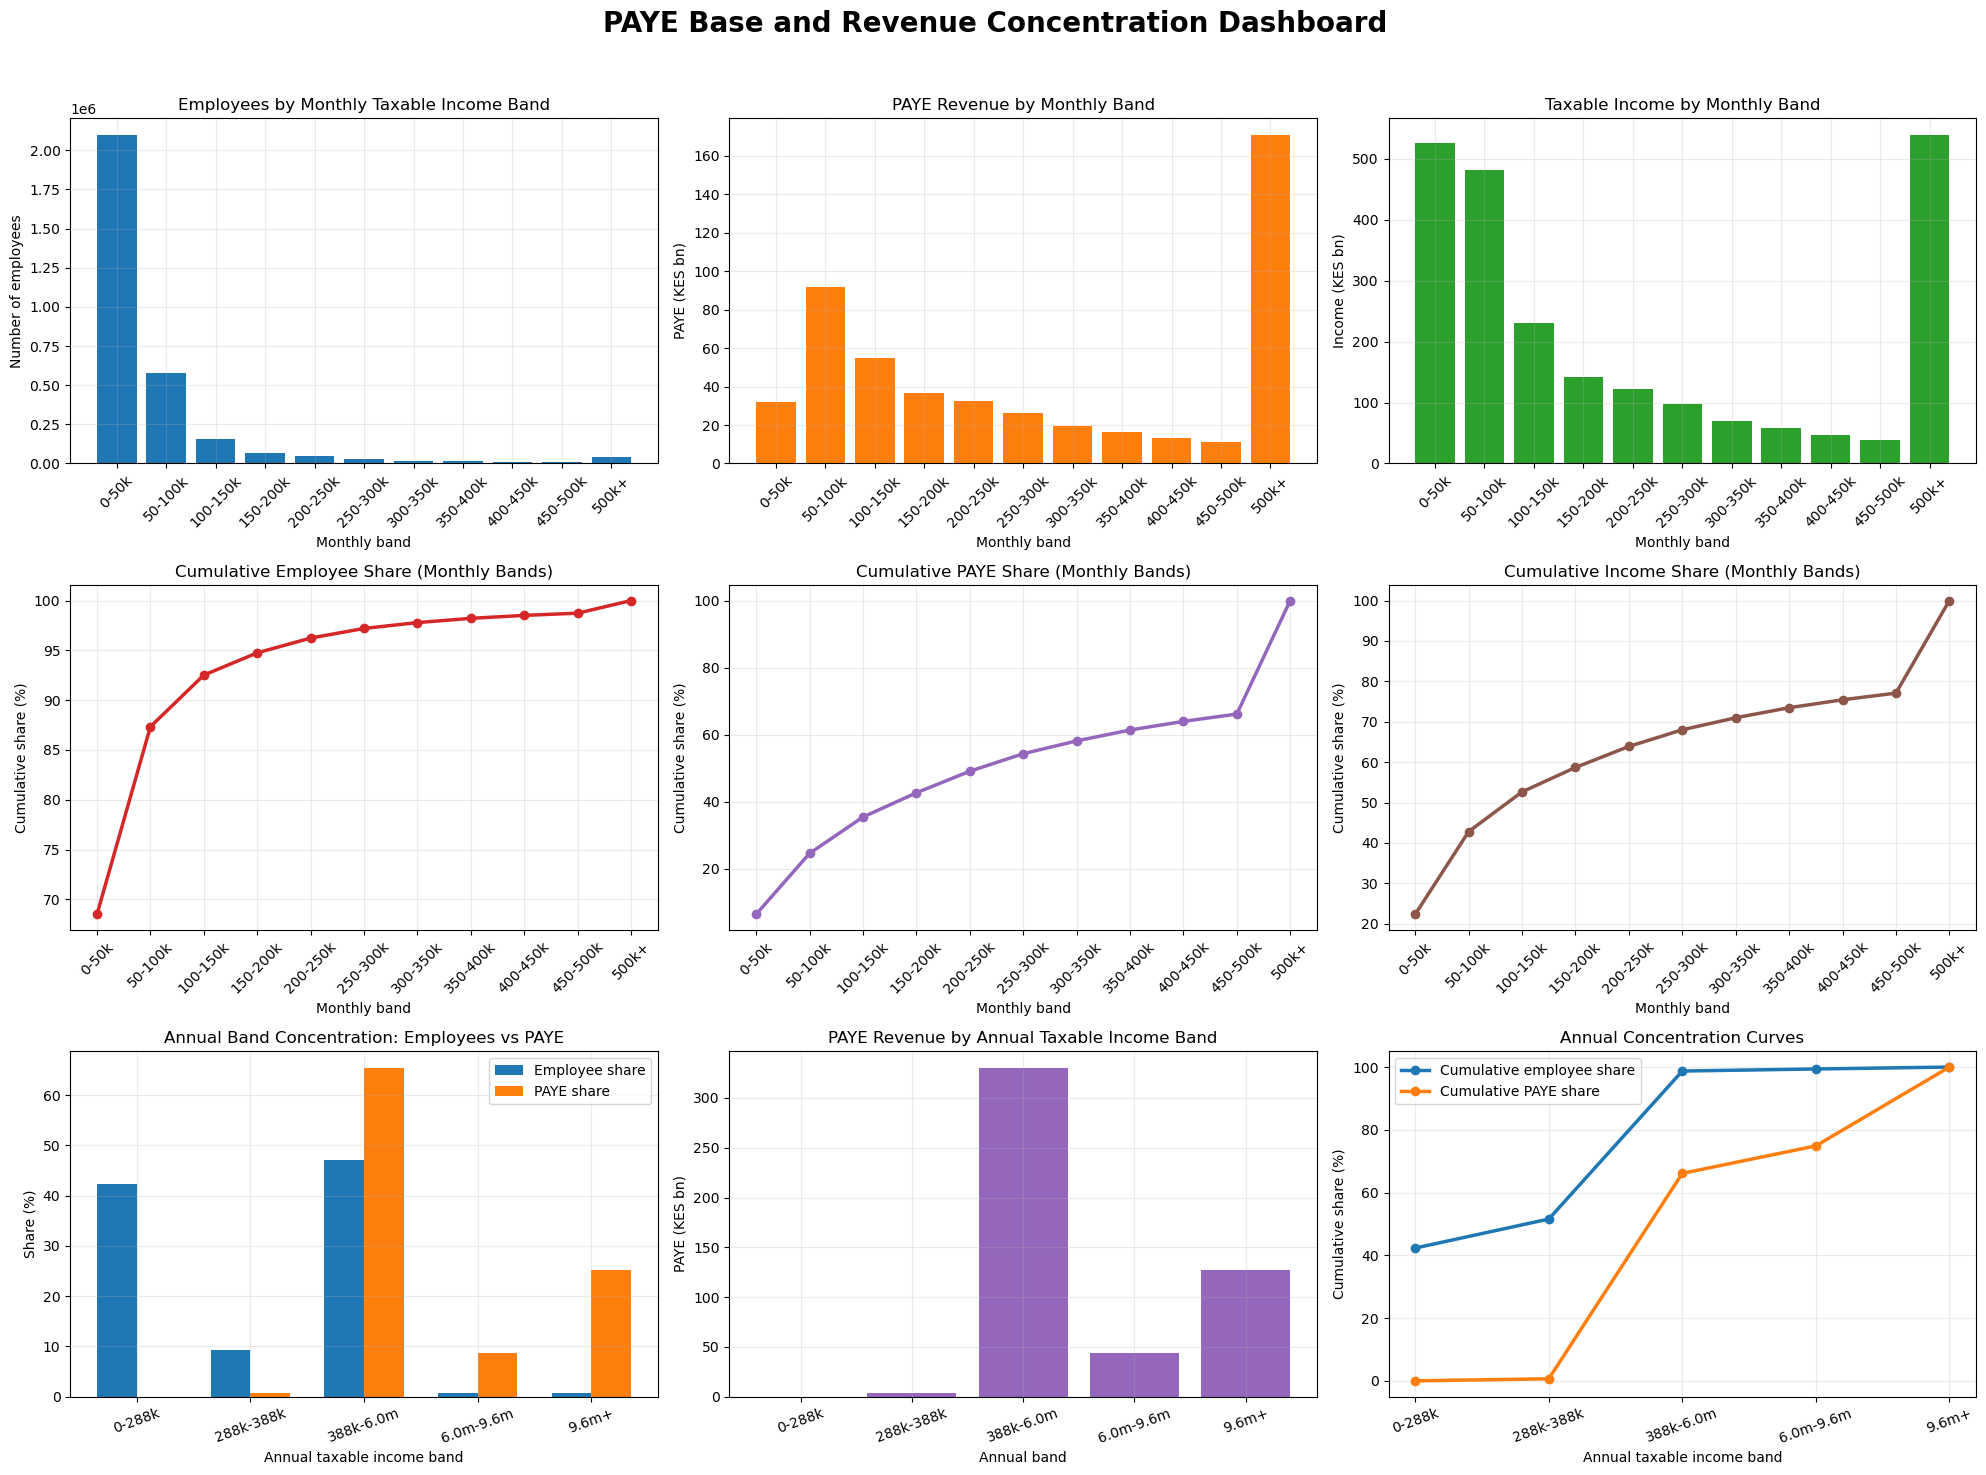

In [20]:
# ============================================================
# 5. VISUALIZE THE PAYE BASE AND REVENUE CONCENTRATION
# 3x3 DASHBOARD
# ============================================================

# -----------------------------
# 1) Compute baseline PAYE
# -----------------------------
def paye_gross_5band(R_arr, b1, b2, b3, b4, r1, r2, r3, r4, r5):
    R_arr = np.asarray(R_arr, dtype=float)
    tax = np.where(
        R_arr <= b1,
        r1 * R_arr,
        np.where(
            R_arr <= b2,
            r1 * b1 + r2 * (R_arr - b1),
            np.where(
                R_arr <= b3,
                r1 * b1 + r2 * (b2 - b1) + r3 * (R_arr - b2),
                np.where(
                    R_arr <= b4,
                    r1 * b1 + r2 * (b2 - b1) + r3 * (b3 - b2) + r4 * (R_arr - b3),
                    r1 * b1 + r2 * (b2 - b1) + r3 * (b3 - b2) + r4 * (b4 - b3) + r5 * (R_arr - b4)
                )
            )
        )
    )
    return np.maximum(tax, 0.0)

def net_paye(gross_tax, relief):
    return np.maximum(gross_tax - relief, 0.0)

df["baseline_paye"] = net_paye(
    paye_gross_5band(
        df["Taxable_Employment_Income"].to_numpy(dtype=float),
        b1, b2, b3, b4,
        r1_base, r2_base, r3_base, r4_base, r5_base
    ),
    relief
)

# -----------------------------
# 2) Monthly taxable income bands
# -----------------------------
df["Monthly_Taxable_Income"] = df["Taxable_Employment_Income"] / 12

monthly_edges = list(range(0, 550000, 50000)) + [np.inf]
monthly_labels = [f"{i//1000}-{(i+50000)//1000}k" for i in range(0, 500000, 50000)] + ["500k+"]

df["monthly_band"] = pd.cut(
    df["Monthly_Taxable_Income"],
    bins=monthly_edges,
    labels=monthly_labels,
    right=False,
    include_lowest=True
)

monthly_summary = (
    df.groupby("monthly_band", observed=False)
      .agg(
          employees=("tax_payer_id", "count"),
          paye=("baseline_paye", "sum"),
          taxable_income=("Taxable_Employment_Income", "sum")
      )
      .reset_index()
)

monthly_summary["employee_share_pct"] = 100 * monthly_summary["employees"] / monthly_summary["employees"].sum()
monthly_summary["paye_share_pct"] = 100 * monthly_summary["paye"] / monthly_summary["paye"].sum()
monthly_summary["income_share_pct"] = 100 * monthly_summary["taxable_income"] / monthly_summary["taxable_income"].sum()

monthly_summary["cum_employee_share_pct"] = monthly_summary["employee_share_pct"].cumsum()
monthly_summary["cum_paye_share_pct"] = monthly_summary["paye_share_pct"].cumsum()
monthly_summary["cum_income_share_pct"] = monthly_summary["income_share_pct"].cumsum()

monthly_summary["paye_bn"] = monthly_summary["paye"] / 1e9
monthly_summary["income_bn"] = monthly_summary["taxable_income"] / 1e9

# -----------------------------
# 3) Annual taxable income bands
# -----------------------------
annual_edges = [0, 288000, 387996, 6000000, 9600000, np.inf]
annual_labels = [
    "0-288k",
    "288k-388k",
    "388k-6.0m",
    "6.0m-9.6m",
    "9.6m+"
]

df["annual_band"] = pd.cut(
    df["Taxable_Employment_Income"],
    bins=annual_edges,
    labels=annual_labels,
    right=False,
    include_lowest=True
)

annual_summary = (
    df.groupby("annual_band", observed=False)
      .agg(
          employees=("tax_payer_id", "count"),
          paye=("baseline_paye", "sum"),
          taxable_income=("Taxable_Employment_Income", "sum")
      )
      .reset_index()
)

annual_summary["employee_share_pct"] = 100 * annual_summary["employees"] / annual_summary["employees"].sum()
annual_summary["paye_share_pct"] = 100 * annual_summary["paye"] / annual_summary["paye"].sum()
annual_summary["income_share_pct"] = 100 * annual_summary["taxable_income"] / annual_summary["taxable_income"].sum()

annual_summary["cum_employee_share_pct"] = annual_summary["employee_share_pct"].cumsum()
annual_summary["cum_paye_share_pct"] = annual_summary["paye_share_pct"].cumsum()
annual_summary["cum_income_share_pct"] = annual_summary["income_share_pct"].cumsum()

annual_summary["paye_bn"] = annual_summary["paye"] / 1e9
annual_summary["income_bn"] = annual_summary["taxable_income"] / 1e9

# -----------------------------
# 4) Display summary tables
# -----------------------------
print("MONTHLY BAND SUMMARY")
display(monthly_summary)

print("ANNUAL BAND SUMMARY")
display(annual_summary)

# -----------------------------
# 5) 3x3 DASHBOARD
# -----------------------------
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
fig.suptitle("PAYE Base and Revenue Concentration Dashboard", fontsize=20, fontweight="bold", y=0.98)

# Color palette
c1 = "#1f77b4"   # blue
c2 = "#ff7f0e"   # orange
c3 = "#2ca02c"   # green
c4 = "#d62728"   # red
c5 = "#9467bd"   # purple
c6 = "#8c564b"   # brown

# 1. Monthly employee counts
axes[0, 0].bar(monthly_summary["monthly_band"].astype(str), monthly_summary["employees"], color=c1)
axes[0, 0].set_title("Employees by Monthly Taxable Income Band")
axes[0, 0].set_xlabel("Monthly band")
axes[0, 0].set_ylabel("Number of employees")
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].grid(True, alpha=0.25)

# 2. Monthly PAYE revenue
axes[0, 1].bar(monthly_summary["monthly_band"].astype(str), monthly_summary["paye_bn"], color=c2)
axes[0, 1].set_title("PAYE Revenue by Monthly Band")
axes[0, 1].set_xlabel("Monthly band")
axes[0, 1].set_ylabel("PAYE (KES bn)")
axes[0, 1].tick_params(axis="x", rotation=45)
axes[0, 1].grid(True, alpha=0.25)

# 3. Monthly taxable income
axes[0, 2].bar(monthly_summary["monthly_band"].astype(str), monthly_summary["income_bn"], color=c3)
axes[0, 2].set_title("Taxable Income by Monthly Band")
axes[0, 2].set_xlabel("Monthly band")
axes[0, 2].set_ylabel("Income (KES bn)")
axes[0, 2].tick_params(axis="x", rotation=45)
axes[0, 2].grid(True, alpha=0.25)

# 4. Cumulative monthly employee share
axes[1, 0].plot(
    monthly_summary["monthly_band"].astype(str),
    monthly_summary["cum_employee_share_pct"],
    marker="o",
    linewidth=2.5,
    color=c4
)
axes[1, 0].set_title("Cumulative Employee Share (Monthly Bands)")
axes[1, 0].set_xlabel("Monthly band")
axes[1, 0].set_ylabel("Cumulative share (%)")
axes[1, 0].tick_params(axis="x", rotation=45)
axes[1, 0].grid(True, alpha=0.25)

# 5. Cumulative PAYE share
axes[1, 1].plot(
    monthly_summary["monthly_band"].astype(str),
    monthly_summary["cum_paye_share_pct"],
    marker="o",
    linewidth=2.5,
    color=c5
)
axes[1, 1].set_title("Cumulative PAYE Share (Monthly Bands)")
axes[1, 1].set_xlabel("Monthly band")
axes[1, 1].set_ylabel("Cumulative share (%)")
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].grid(True, alpha=0.25)

# 6. Cumulative taxable income share
axes[1, 2].plot(
    monthly_summary["monthly_band"].astype(str),
    monthly_summary["cum_income_share_pct"],
    marker="o",
    linewidth=2.5,
    color=c6
)
axes[1, 2].set_title("Cumulative Income Share (Monthly Bands)")
axes[1, 2].set_xlabel("Monthly band")
axes[1, 2].set_ylabel("Cumulative share (%)")
axes[1, 2].tick_params(axis="x", rotation=45)
axes[1, 2].grid(True, alpha=0.25)

# 7. Annual concentration: employee vs revenue share
x = np.arange(len(annual_summary))
width = 0.35

axes[2, 0].bar(x - width/2, annual_summary["employee_share_pct"], width=width, label="Employee share", color=c1)
axes[2, 0].bar(x + width/2, annual_summary["paye_share_pct"], width=width, label="PAYE share", color=c2)
axes[2, 0].set_title("Annual Band Concentration: Employees vs PAYE")
axes[2, 0].set_xlabel("Annual taxable income band")
axes[2, 0].set_ylabel("Share (%)")
axes[2, 0].set_xticks(x)
axes[2, 0].set_xticklabels(annual_summary["annual_band"].astype(str), rotation=20)
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.25)

# 8. Annual PAYE by band
axes[2, 1].bar(annual_summary["annual_band"].astype(str), annual_summary["paye_bn"], color=c5)
axes[2, 1].set_title("PAYE Revenue by Annual Taxable Income Band")
axes[2, 1].set_xlabel("Annual band")
axes[2, 1].set_ylabel("PAYE (KES bn)")
axes[2, 1].tick_params(axis="x", rotation=20)
axes[2, 1].grid(True, alpha=0.25)

# 9. Annual cumulative concentration
axes[2, 2].plot(
    annual_summary["annual_band"].astype(str),
    annual_summary["cum_employee_share_pct"],
    marker="o",
    linewidth=2.5,
    label="Cumulative employee share",
    color=c1
)
axes[2, 2].plot(
    annual_summary["annual_band"].astype(str),
    annual_summary["cum_paye_share_pct"],
    marker="o",
    linewidth=2.5,
    label="Cumulative PAYE share",
    color=c2
)
axes[2, 2].set_title("Annual Concentration Curves")
axes[2, 2].set_xlabel("Annual taxable income band")
axes[2, 2].set_ylabel("Cumulative share (%)")
axes[2, 2].tick_params(axis="x", rotation=20)
axes[2, 2].legend()
axes[2, 2].grid(True, alpha=0.25)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(r"C:\Users\hp\OneDrive\Documents\PAYE simulation grid\paye_dashboard.png", dpi=300, bbox_inches="tight")
plt.show()

### Observations from the PAYE Base

The distribution of employees and PAYE revenue across income bands reveals a highly skewed tax base.

**Employee distribution**

- A large majority of employees earn relatively low monthly incomes.
- About **68% of employees earn below KES 50,000 per month**, and **over 87% earn below KES 100,000**.
- High-income earners are extremely small in number, with only **about 1.3% earning above KES 500,000 per month**.

**Revenue concentration**

- Despite their small numbers, high-income earners contribute a disproportionate share of PAYE revenue.
- Individuals earning **above KES 500,000 per month generate about 34% of total PAYE revenue**.
- In contrast, the large group earning **below KES 50,000 contributes only about 6% of PAYE revenue**.

**Annual PAYE structure**

- Employees earning **below the personal relief threshold (KES 288,000 annually)** account for **over 42% of workers but pay no PAYE**.
- The majority of PAYE revenue comes from the **388k–6.0m annual income group**, which contributes about **65% of total PAYE revenue**.
- Very high-income taxpayers (above **KES 9.6m annually**) represent less than **1% of employees but contribute roughly 25% of PAYE revenue**.

**Implication**

The PAYE system relies heavily on a relatively small share of higher-income taxpayers, while a large portion of the workforce contributes little or no income tax. This structure is an important consideration when evaluating alternative tax rate scenarios in the simulation that follows.

## 6. Define the PAYE Simulation Grid
The simulation keeps the first-band rate fixed at **10%** and varies the higher marginal rates across a structured grid. This generates the policy space used to evaluate alternative PAYE structures in terms of both **revenue yield** and **progressivity**.

In [9]:
# ============================================================
# 6. DEFINE THE PAYE SIMULATION GRID
# ============================================================

# Fixed lower-band rate
r1_fixed = 0.10

# Baseline rates for reference
r2_base = 0.25
r3_base = 0.30
r4_base = 0.325
r5_base = 0.35

# Grid step = 0.5 percentage points
step = 0.005

# Rate grids to be simulated
r2_grid = np.round(np.arange(0.25, 0.30 + step/2, step), 3)
r3_grid = np.round(np.arange(0.30, 0.325 + step/2, step), 3)
r4_grid = np.round(np.arange(0.325, 0.35 + step/2, step), 3)
r5_grid = np.round(np.arange(0.35, 0.40 + step/2, step), 3)

print("Simulation grid defined.")
print(f"r2 values: {r2_grid}")
print(f"r3 values: {r3_grid}")
print(f"r4 values: {r4_grid}")
print(f"r5 values: {r5_grid}")
print(f"Total raw combinations: {len(r2_grid) * len(r3_grid) * len(r4_grid) * len(r5_grid):,}")

Simulation grid defined.
r2 values: [0.25  0.255 0.26  0.265 0.27  0.275 0.28  0.285 0.29  0.295 0.3  ]
r3 values: [0.3   0.305 0.31  0.315 0.32  0.325]
r4 values: [0.325 0.33  0.335 0.34  0.345 0.35 ]
r5 values: [0.35  0.355 0.36  0.365 0.37  0.375 0.38  0.385 0.39  0.395 0.4  ]
Total raw combinations: 4,356


## 7. Define the PAYE Simulation Engine and Inequality Metrics

This section defines the functions used to simulate PAYE liabilities and evaluate the distributional effects of alternative tax rate structures.

### PAYE computation

PAYE liability is calculated using the statutory five-band marginal tax schedule applied to **annual taxable employment income**. For each taxpayer, tax is computed sequentially across the income brackets:

- **Band 1:** up to KES 288,000  
- **Band 2:** KES 288,001 – 387,996  
- **Band 3:** KES 387,997 – 6,000,000  
- **Band 4:** KES 6,000,001 – 9,600,000  
- **Band 5:** above KES 9,600,000  

The tax function computes **gross PAYE liability** using marginal rates applied to each bracket. Personal relief is then deducted to obtain **net PAYE payable**, ensuring that tax cannot fall below zero.

### Simulation approach

The PAYE simulation engine applies this tax function to the full population of taxpayers. For each scenario in the simulation grid:

1. A new set of marginal rates (r2–r5) is applied.
2. PAYE is computed for every taxpayer.
3. Total PAYE revenue is aggregated.
4. Distributional metrics are calculated.

This allows the model to evaluate how alternative tax rate structures affect both **government revenue** and the **progressivity of the tax system**.

### Inequality and progressivity measures

Three related indicators are computed:

**Gini coefficient**

The Gini coefficient measures inequality in the distribution of **taxable income** across taxpayers.

**Concentration index**

The concentration index measures how tax payments are distributed across the income distribution. If higher-income taxpayers contribute a larger share of tax, the concentration index will be high.

**Kakwani progressivity index**

Tax progressivity is measured using the Kakwani index:

Kakwani = Concentration Index of Taxes − Gini of Income

A positive Kakwani index indicates a **progressive tax system**, meaning higher-income individuals contribute a disproportionately larger share of taxes relative to their income.

These metrics allow the simulation to evaluate the trade-off between **revenue generation** and **tax progressivity** across different PAYE rate structures.

In [10]:
# ============================================================
# 7. DEFINE THE PAYE SIMULATION ENGINE AND INEQUALITY METRICS
# ============================================================

def paye_gross_5band(R_arr, b1, b2, b3, b4, r1, r2, r3, r4, r5):
    """
    Compute gross PAYE using a five-band marginal tax schedule.

    Parameters
    ----------
    R_arr : array-like
        Annual taxable employment income.
    b1, b2, b3, b4 : float
        Upper thresholds for Bands 1 to 4.
    r1, r2, r3, r4, r5 : float
        Marginal tax rates for Bands 1 to 5.

    Returns
    -------
    numpy.ndarray
        Gross PAYE liability before personal relief.
    """
    R_arr = np.asarray(R_arr, dtype=float)

    tax = np.where(
        R_arr <= b1,
        r1 * R_arr,
        np.where(
            R_arr <= b2,
            r1 * b1 + r2 * (R_arr - b1),
            np.where(
                R_arr <= b3,
                r1 * b1 + r2 * (b2 - b1) + r3 * (R_arr - b2),
                np.where(
                    R_arr <= b4,
                    r1 * b1 + r2 * (b2 - b1) + r3 * (b3 - b2) + r4 * (R_arr - b3),
                    r1 * b1 + r2 * (b2 - b1) + r3 * (b3 - b2) + r4 * (b4 - b3) + r5 * (R_arr - b4)
                )
            )
        )
    )

    return np.maximum(tax, 0.0)


def net_paye(gross_tax, relief):
    """
    Compute net PAYE after personal relief.
    Tax liability cannot fall below zero.
    """
    return np.maximum(gross_tax - relief, 0.0)


def gini(x):
    """
    Compute the Gini coefficient of income.
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return np.nan
    if np.all(x == 0):
        return 0.0

    x = np.sort(x)
    n = len(x)
    cumx = np.cumsum(x)

    return (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n


def concentration_index(tax, income):
    """
    Compute the concentration index of tax payments ranked by income.
    """
    tax = np.asarray(tax, dtype=float)
    income = np.asarray(income, dtype=float)

    mask = np.isfinite(tax) & np.isfinite(income)
    tax = tax[mask]
    income = income[mask]

    if len(tax) == 0:
        return np.nan
    if np.all(tax == 0):
        return 0.0

    order = np.argsort(income)
    tax = tax[order]

    n = len(tax)
    cumtax = np.cumsum(tax)

    return (n + 1 - 2 * np.sum(cumtax) / cumtax[-1]) / n


def kakwani_index(tax, income):
    """
    Compute the Kakwani progressivity index.

    Kakwani = Concentration index of taxes - Gini coefficient of income
    """
    g = gini(income)
    c = concentration_index(tax, income)
    return c - g, g, c


print("PAYE simulation engine and inequality metrics defined.")

PAYE simulation engine and inequality metrics defined.


## 8. Compute Baseline PAYE Revenue and Progressivity
Before running the simulation grid, we compute the **baseline PAYE system** using the current marginal tax rates.

The baseline serves as the reference point for evaluating alternative tax systems. For the baseline structure:

- **r1 = 10%**
- **r2 = 25%**
- **r3 = 30%**
- **r4 = 32.5%**
- **r5 = 35%**

Personal relief is fixed at **KES 28,800**.

For this baseline system we compute:

- Total PAYE revenue
- The Gini coefficient of taxable income
- The concentration index of PAYE payments
- The Kakwani progressivity index

All simulated tax systems will later be compared against this baseline in terms of **revenue change** and **progressivity**.

In [11]:
# ============================================================
# 8. BASELINE PAYE SYSTEM
# ============================================================

base_gross = paye_gross_5band(
    R,
    b1, b2, b3, b4,
    r1_fixed, r2_base, r3_base, r4_base, r5_base
)

base_net = net_paye(base_gross, relief)

baseline_revenue = base_net.sum()

baseline_kakwani, baseline_gini, baseline_conc = kakwani_index(base_net, R)

print("BASELINE RESULTS")
print("----------------")
print("Baseline PAYE revenue (KES bn):", round(baseline_revenue / 1e9, 3))
print("Gini coefficient (income):", round(baseline_gini, 6))
print("Tax concentration index:", round(baseline_conc, 6))
print("Kakwani progressivity index:", round(baseline_kakwani, 6))

BASELINE RESULTS
----------------
Baseline PAYE revenue (KES bn): 504.626
Gini coefficient (income): 0.639394
Tax concentration index: 0.828171
Kakwani progressivity index: 0.188777


## 9.  PAYE Rate Simulation Grid

This section evaluates the full grid of PAYE tax rate combinations defined earlier.

For each combination of marginal rates \(r_2, r_3, r_4, r_5\), the simulation:

1. Recomputes PAYE liabilities for every taxpayer.
2. Aggregates total PAYE revenue.
3. Measures the change in revenue relative to the baseline.
4. Computes the concentration index of tax payments.
5. Calculates the Kakwani progressivity index.

The result is a **policy simulation grid** describing how different PAYE rate structures affect both **revenue generation** and **tax progressivity**.

In [13]:
# ============================================================
# 9A. RUN PAYE RATE SIMULATION GRID
# ============================================================

results = []

for r2 in r2_grid:
    for r3 in r3_grid:
        for r4 in r4_grid:
            for r5 in r5_grid:

                gross_tax = paye_gross_5band(
                    R,
                    b1, b2, b3, b4,
                    r1_fixed, r2, r3, r4, r5
                )

                net_tax = net_paye(gross_tax, relief)

                revenue = net_tax.sum()

                kakwani, gini_income, conc_tax = kakwani_index(net_tax, R)

                results.append({
                    "r2": r2,
                    "r3": r3,
                    "r4": r4,
                    "r5": r5,
                    "revenue": revenue,
                    "revenue_bn": revenue / 1e9,
                    "revenue_change_bn": (revenue - baseline_revenue) / 1e9,
                    "gini_income": gini_income,
                    "concentration_tax": conc_tax,
                    "kakwani": kakwani
                })

sim_grid = pd.DataFrame(results)

print("Simulation grid complete.")
print("Total systems evaluated:", len(sim_grid))

sim_grid.head(100)

Simulation grid complete.
Total systems evaluated: 4356


,r2,r3,r4,r5,revenue,revenue_bn,revenue_change_bn,gini_income,concentration_tax,kakwani
0,0.25,0.3,0.325,0.350,5.046256e+11,504.625568,0.000000,0.639394,0.828171,0.188777
1,0.25,0.3,0.325,0.355,5.056655e+11,505.665515,1.039947,0.639394,0.828521,0.189126
2,0.25,0.3,0.325,0.360,5.067055e+11,506.705462,2.079894,0.639394,0.828868,0.189474
3,0.25,0.3,0.325,0.365,5.077454e+11,507.745408,3.119841,0.639394,0.829215,0.189821
4,0.25,0.3,0.325,0.370,5.087854e+11,508.785355,4.159788,0.639394,0.829559,0.190165


In [17]:
# ============================================================
# 9B. WE SAVE FULL SIMULATION RESULTS
# ============================================================

output_path = r"C:\Users\hp\OneDrive\Documents\PAYE simulation grid\paye_grid_r2_r5_full_data.xlsx"

sim_grid.to_excel(output_path, sheet_name="all_scenarios", index=False)

print("Simulation results saved to:")
print(output_path)

Simulation results saved to:
C:\Users\hp\OneDrive\Documents\PAYE simulation grid\paye_grid_r2_r5_full_data.xlsx


## 10. Visualize the Revenue–Equity Policy Space

This section uses the completed simulation results to map the **PAYE policy space** and identify efficient tax structures.

The dashboard summarizes three analytical dimensions of the simulation output:

- **Policy space:** the relationship between total PAYE revenue and the Kakwani progressivity index across all simulated tax systems
- **Revenue sensitivity:** how revenue changes as higher-band marginal tax rates increase
- **Efficient PAYE structures:** the subset of simulated rate combinations that lie on the **Pareto frontier**, where no other system delivers both higher revenue and higher progressivity

Each point in the dashboard represents a simulated PAYE structure defined by a distinct combination of **r2, r3, r4, and r5**, with **r1 fixed at 10 percent** and **personal relief held constant**.

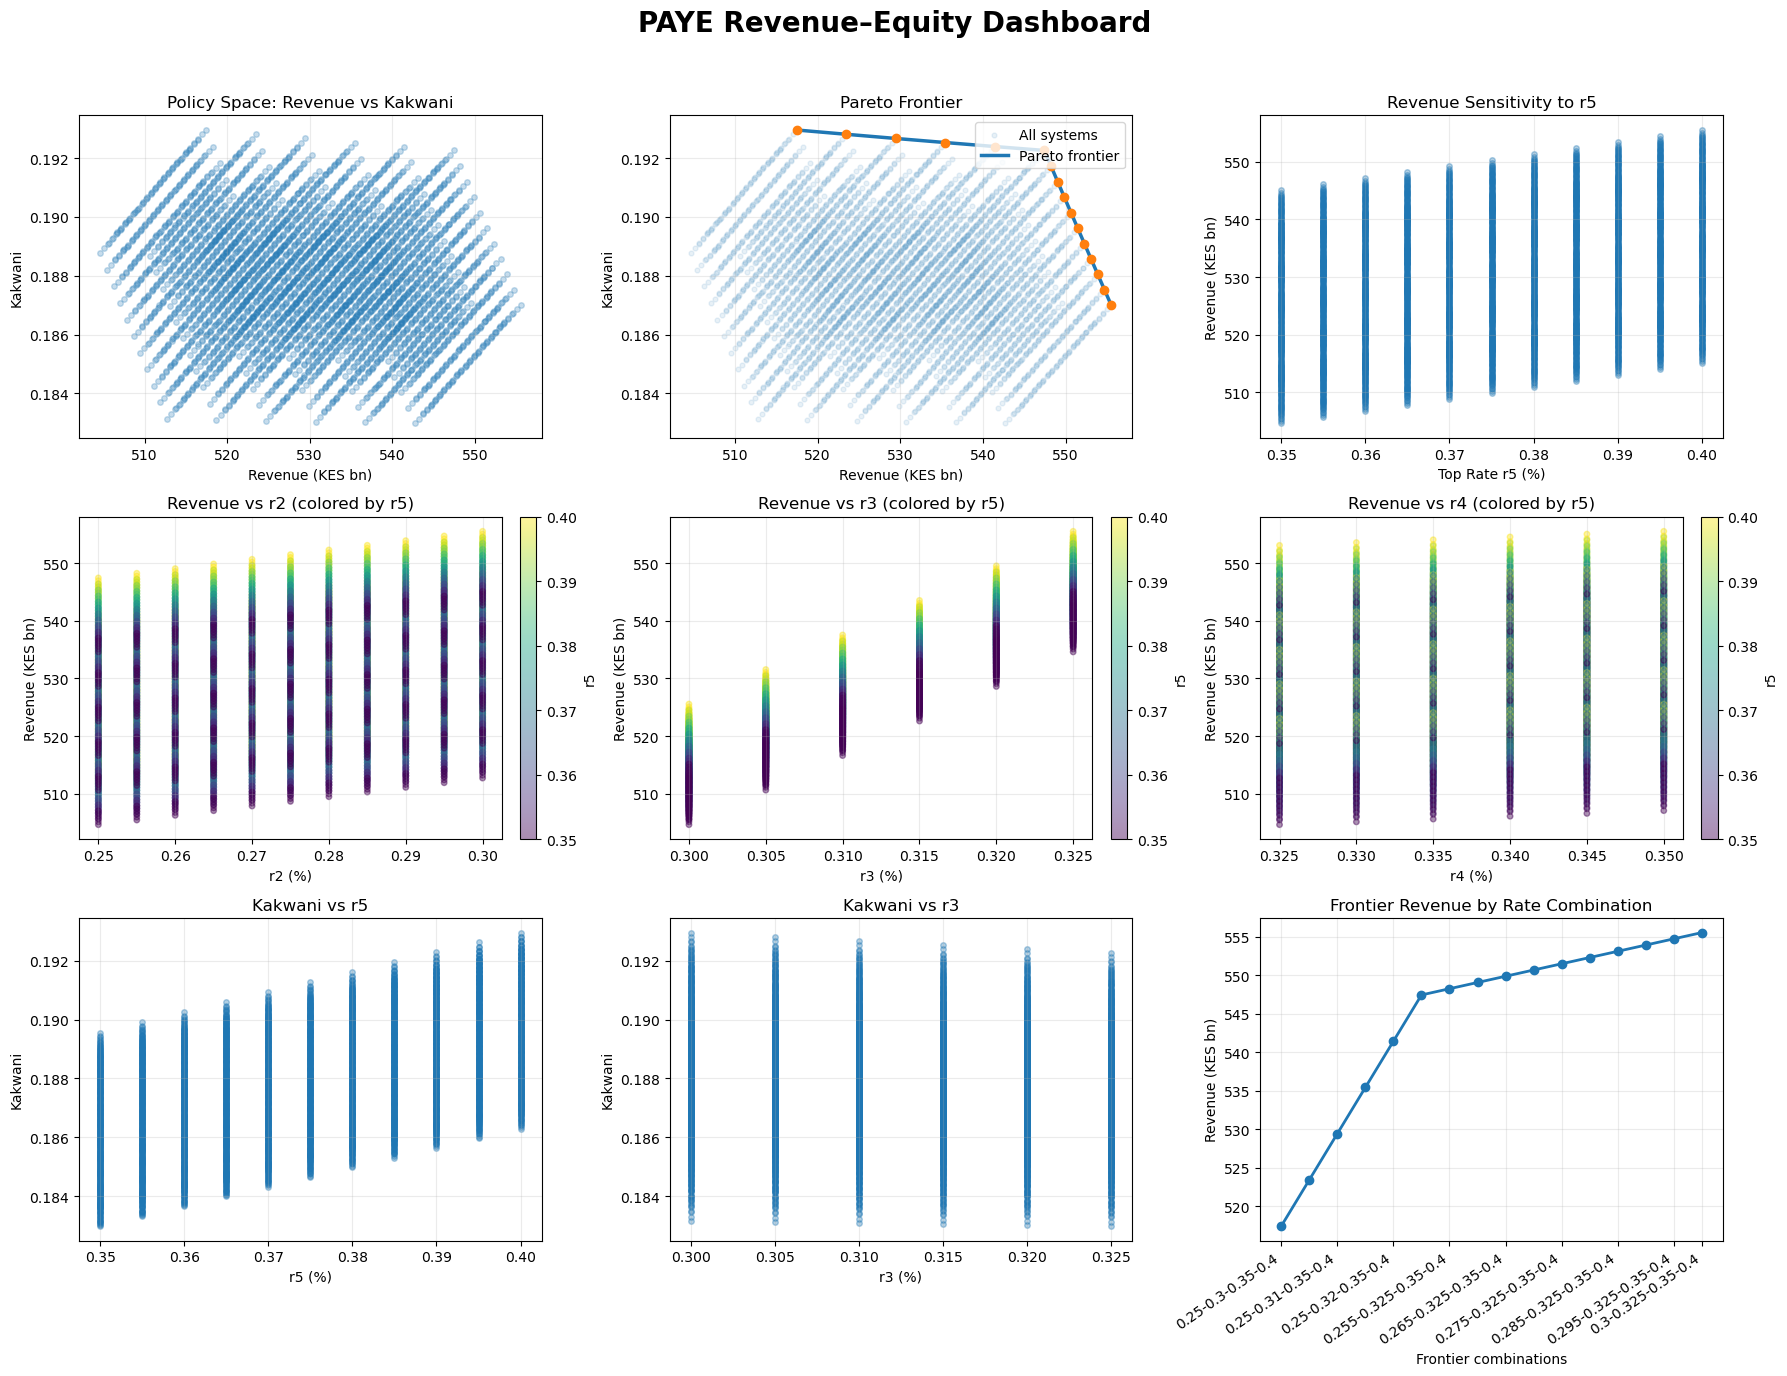

In [22]:
# ============================================================
# 10. VISUALIZE THE REVENUE–EQUITY POLICY SPACE
# ============================================================

# Use simulation results already created in memory
df_plot = sim_grid.copy()

# Rename for consistency with dashboard labels
df_plot = df_plot.rename(columns={
    "revenue_bn": "scenario_revenue_bn",
    "revenue_change_bn": "delta_revenue_bn",
    "kakwani": "kakwani_index"
})

# -----------------------------
# Build Pareto frontier
# Keep non-dominated points:
# from highest revenue downward, keep only points with
# strictly higher Kakwani than any higher-revenue point
# -----------------------------
df_desc = df_plot.sort_values("scenario_revenue_bn", ascending=False).copy()

frontier_rows = []
best_k = float("-inf")

for _, row in df_desc.iterrows():
    if row["kakwani_index"] > best_k:
        frontier_rows.append(row)
        best_k = row["kakwani_index"]

frontier = (
    pd.DataFrame(frontier_rows)
    .sort_values("scenario_revenue_bn")
    .reset_index(drop=True)
)

# Rate-combination label for frontier plot
frontier["combo"] = (
    frontier["r2"].astype(str) + "-" +
    frontier["r3"].astype(str) + "-" +
    frontier["r4"].astype(str) + "-" +
    frontier["r5"].astype(str)
)

# -----------------------------
# Plot settings
# -----------------------------
plt.style.use("default")

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle("PAYE Revenue–Equity Dashboard", fontsize=20, fontweight="bold", y=0.98)

# PANEL 1: POLICY CLOUD
axes[0, 0].scatter(
    df_plot["scenario_revenue_bn"],
    df_plot["kakwani_index"],
    alpha=0.25,
    s=16
)
axes[0, 0].set_title("Policy Space: Revenue vs Kakwani")
axes[0, 0].set_xlabel("Revenue (KES bn)")
axes[0, 0].set_ylabel("Kakwani")
axes[0, 0].grid(True, alpha=0.25)

# PANEL 2: PARETO FRONTIER
axes[0, 1].scatter(
    df_plot["scenario_revenue_bn"],
    df_plot["kakwani_index"],
    alpha=0.10,
    s=12,
    label="All systems"
)
axes[0, 1].plot(
    frontier["scenario_revenue_bn"],
    frontier["kakwani_index"],
    linewidth=2.5,
    label="Pareto frontier"
)
axes[0, 1].scatter(
    frontier["scenario_revenue_bn"],
    frontier["kakwani_index"],
    s=36,
    zorder=3
)
axes[0, 1].set_title("Pareto Frontier")
axes[0, 1].set_xlabel("Revenue (KES bn)")
axes[0, 1].set_ylabel("Kakwani")
axes[0, 1].grid(True, alpha=0.25)
axes[0, 1].legend(frameon=True)

# PANEL 3: REVENUE SENSITIVITY TO r5
axes[0, 2].scatter(
    df_plot["r5"],
    df_plot["scenario_revenue_bn"],
    alpha=0.35,
    s=16
)
axes[0, 2].set_title("Revenue Sensitivity to r5")
axes[0, 2].set_xlabel("Top Rate r5 (%)")
axes[0, 2].set_ylabel("Revenue (KES bn)")
axes[0, 2].grid(True, alpha=0.25)

# PANEL 4: REVENUE vs r2 (COLORED BY r5)
sc1 = axes[1, 0].scatter(
    df_plot["r2"],
    df_plot["scenario_revenue_bn"],
    c=df_plot["r5"],
    cmap="viridis",
    alpha=0.45,
    s=16
)
axes[1, 0].set_title("Revenue vs r2 (colored by r5)")
axes[1, 0].set_xlabel("r2 (%)")
axes[1, 0].set_ylabel("Revenue (KES bn)")
axes[1, 0].grid(True, alpha=0.25)
cbar1 = fig.colorbar(sc1, ax=axes[1, 0], fraction=0.046, pad=0.04)
cbar1.set_label("r5")

# PANEL 5: REVENUE vs r3 (COLORED BY r5)
sc2 = axes[1, 1].scatter(
    df_plot["r3"],
    df_plot["scenario_revenue_bn"],
    c=df_plot["r5"],
    cmap="viridis",
    alpha=0.45,
    s=16
)
axes[1, 1].set_title("Revenue vs r3 (colored by r5)")
axes[1, 1].set_xlabel("r3 (%)")
axes[1, 1].set_ylabel("Revenue (KES bn)")
axes[1, 1].grid(True, alpha=0.25)
cbar2 = fig.colorbar(sc2, ax=axes[1, 1], fraction=0.046, pad=0.04)
cbar2.set_label("r5")

# PANEL 6: REVENUE vs r4 (COLORED BY r5)
sc3 = axes[1, 2].scatter(
    df_plot["r4"],
    df_plot["scenario_revenue_bn"],
    c=df_plot["r5"],
    cmap="viridis",
    alpha=0.45,
    s=16
)
axes[1, 2].set_title("Revenue vs r4 (colored by r5)")
axes[1, 2].set_xlabel("r4 (%)")
axes[1, 2].set_ylabel("Revenue (KES bn)")
axes[1, 2].grid(True, alpha=0.25)
cbar3 = fig.colorbar(sc3, ax=axes[1, 2], fraction=0.046, pad=0.04)
cbar3.set_label("r5")

# PANEL 7: KAKWANI vs r5
axes[2, 0].scatter(
    df_plot["r5"],
    df_plot["kakwani_index"],
    alpha=0.35,
    s=16
)
axes[2, 0].set_title("Kakwani vs r5")
axes[2, 0].set_xlabel("r5 (%)")
axes[2, 0].set_ylabel("Kakwani")
axes[2, 0].grid(True, alpha=0.25)

# PANEL 8: KAKWANI vs r3
axes[2, 1].scatter(
    df_plot["r3"],
    df_plot["kakwani_index"],
    alpha=0.35,
    s=16
)
axes[2, 1].set_title("Kakwani vs r3")
axes[2, 1].set_xlabel("r3 (%)")
axes[2, 1].set_ylabel("Kakwani")
axes[2, 1].grid(True, alpha=0.25)

# PANEL 9: FRONTIER REVENUE BY RATE COMBINATION
axes[2, 2].plot(
    range(len(frontier)),
    frontier["scenario_revenue_bn"],
    marker="o",
    linewidth=2
)
axes[2, 2].set_title("Frontier Revenue by Rate Combination")
axes[2, 2].set_xlabel("Frontier combinations")
axes[2, 2].set_ylabel("Revenue (KES bn)")
axes[2, 2].grid(True, alpha=0.25)

tick_idx = list(range(0, len(frontier), max(1, len(frontier) // 6)))
if (len(frontier) - 1) not in tick_idx:
    tick_idx.append(len(frontier) - 1)

axes[2, 2].set_xticks(tick_idx)
axes[2, 2].set_xticklabels(
    frontier["combo"].iloc[tick_idx],
    rotation=35,
    ha="right"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(r"C:\Users\hp\OneDrive\Documents\PAYE simulation grid\paye_revenue_equity_dashboard.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation of the Revenue–Equity Dashboard

Each panel highlights a different aspect of the PAYE policy trade-off between **revenue generation** and **tax progressivity**.

**Policy Space: Revenue vs Kakwani**  
Each point represents a simulated PAYE structure; the upward-sloping cloud indicates that higher revenue systems are generally also more progressive within the simulated rate range.

**Pareto Frontier**  
The frontier identifies the set of tax systems that are **policy-efficient**, meaning no other simulated structure delivers both higher revenue and higher progressivity.

**Revenue Sensitivity to r5**  
Revenue rises steadily as the top marginal rate increases, showing that **PAYE collections are highly sensitive to the top tax band**.

**Revenue vs r2 (colored by r5)**  
Changes in the second marginal rate affect revenue modestly, but the color gradient shows that **higher top rates dominate the revenue outcome**.

**Revenue vs r3 (colored by r5)**  
Adjustments to the middle band influence revenue, but again the largest revenue gains occur when **higher r5 values are combined with higher r3 rates**.

**Revenue vs r4 (colored by r5)**  
Revenue increases with the fourth-band rate, though the dispersion indicates that **top-band taxation still plays the dominant role in determining total PAYE receipts**.

**Kakwani vs r5**  
Progressivity increases consistently with the top marginal rate, indicating that **higher r5 strengthens the redistributive effect of the PAYE system**.

**Kakwani vs r3**  
Changes in the middle tax band have relatively small effects on overall progressivity, suggesting **distributional outcomes are driven mainly by the upper tax brackets**.

**Frontier Revenue by Rate Combination**  
This panel shows the sequence of efficient rate structures along the frontier, illustrating the **incremental revenue gains achievable while maintaining the highest possible progressivity at each step**.